In [1]:
%pip install -e ..

Obtaining file:///Users/pratikeliasjacob/Documents/Projects/simple-transformer
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for simple-transformer (pyproject.toml) ... done
  Created wheel for simple-transformer: filename=simple_transformer-0.1.0-0.editable-py3-none-any.whl size=2129 sha256=cddbca93b7c3b81b3f8b24ce71302f920c2f6cf0c452cb2c522cfce3a99552a4
  Stored in directory: /private/var/folders/qn/79klx_zs0m1fqrh1q4c5ql_00000gn/T/pip-ephem-wheel-cache-qbsqoqry/wheels/de/d4/87/c813e0cb6465938cfd1c4350e8aa954bcfb9b50edc775763b4
Successfully built simple-transformer
  Attempting uninstall: simple-transformer
    Found existing installation: simple-transformer 0.1.0
    Uninstalling simple-transformer-0.1.0:
      Successfully uninstalled simple-transformer-0.1.0
Note: you may need to restart the kernel to 

In [2]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from simple_transformer.checkpoint import CheckpointConfig, CheckpointManager
from simple_transformer.config import local_training_config, small_model_config
from simple_transformer.metrics import TensorBoardTrainingObserver
from simple_transformer.model import SimpleTransformerLM, count_parameters
from simple_transformer.data import make_train_val_loaders
from simple_transformer.train import fit


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.0
cpu


In [4]:
custom_examples = [
    "0+0=",
    "5+7=",
    "9+1=",
    "10+5=",
    "45+54=",
    "99+1=",
    "123+456=",
    "999+1=",
    "745+84=",
    "12+385=",
    "1000+0=",
    "1005+2000=",
    "1234+1111=",
    "4096+2048=",
    "9999+1=",
    "9999+9999=",
]

for example in custom_examples:
    print(example)

0+0=
5+7=
9+1=
10+5=
45+54=
99+1=
123+456=
999+1=
745+84=
12+385=
1000+0=
1005+2000=
1234+1111=
4096+2048=
9999+1=
9999+9999=


In [5]:
def show_generations(model, tokenizer, examples):
    model.eval()
    prompt_ids = [tokenizer.encode(example) for example in examples]
    generated_ids = model.generate_batch(
        prompt_ids,
        eos_token_id=tokenizer.eos_token_id,
    )

    for prompt, output_ids in zip(examples, generated_ids):
        print(f"{prompt:>8} -> {tokenizer.decode(output_ids)}")

In [6]:
train_config = local_training_config(max_digits=4, device=device)

model_config = small_model_config(
    max_digits=train_config.max_digits,
    device=train_config.device,
)
model = SimpleTransformerLM(model_config)
train_loader, val_loader, tokenizer = make_train_val_loaders(train_config)
run_name = datetime.now().strftime("addition-%Y%m%d-%H%M%S")
run_dir = Path("..") / "runs" / run_name
checkpoint_dir = Path("..") / "checkpoints" / run_name
checkpoint_manager = CheckpointManager(
    CheckpointConfig(checkpoint_dir=checkpoint_dir, keep_last=3)
)
observer = TensorBoardTrainingObserver(run_dir)
observer.log_config(
    training_config=train_config,
    model_config=model_config,
    parameter_count=count_parameters(model),
)

print(f"parameters: {count_parameters(model):,}")
print(f"force flash: {model_config.force_flash}")
print(f"train batches: {len(train_loader)}, validation batches: {len(val_loader)}")
print(f"TensorBoard log dir: {run_dir}")
print(f"Checkpoint dir: {checkpoint_dir}")
print("Terminal: tensorboard --logdir runs")
print("Before training:")
show_generations(model, tokenizer, custom_examples)


parameters: 2,032,320
force flash: False
train batches: 1024, validation batches: 256
TensorBoard log dir: ../runs/addition-20260619-193654
Checkpoint dir: ../checkpoints/addition-20260619-193654
Terminal: tensorboard --logdir runs
Before training:
    0+0= -> 0+0=000000000000
    5+7= -> 5+7===0000000000
    9+1= -> 9+1=++++++++++++
   10+5= -> 10+5=99999999999
  45+54= -> 45+54=5555555555
   99+1= -> 99+1=+++++++++++
123+456= -> 123+456=99999999
  999+1= -> 999+1=++++++++++
 745+84= -> 745+84=000000000
 12+385= -> 12+385=999999999
 1000+0= -> 1000+0=666666666
1005+2000= -> 1005+2000=666666
1234+1111= -> 1234+1111=999999
4096+2048= -> 4096+2048=999999
 9999+1= -> 9999+1=+++++++++
9999+9999= -> 9999+9999=++++++


In [7]:
def print_epoch(epoch, train, validation):
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train.loss:.4f} acc {train.accuracy:.3f} | "
        f"val loss {validation.loss:.4f} acc {validation.accuracy:.3f} | "
        f"lr {train.learning_rate:.2e}"
    )

try:
    history = fit(
        model,
        train_loader,
        val_loader,
        train_config,
        on_epoch=print_epoch,
        observer=observer,
        checkpoint_manager=checkpoint_manager,
    )¬
finally:
    observer.close()
    checkpoint_manager.close()


epoch 01 | train loss 1.4932 acc 0.426 | val loss 1.3342 acc 0.482 | lr 2.98e-04
epoch 02 | train loss 0.6857 acc 0.739 | val loss 0.1690 acc 0.938 | lr 2.93e-04
epoch 03 | train loss 0.1514 acc 0.944 | val loss 0.1409 acc 0.947 | lr 2.85e-04
epoch 04 | train loss 0.1308 acc 0.951 | val loss 0.1175 acc 0.954 | lr 2.74e-04
epoch 05 | train loss 0.0911 acc 0.964 | val loss 0.0640 acc 0.976 | lr 2.61e-04
epoch 06 | train loss 0.0435 acc 0.984 | val loss 0.0321 acc 0.989 | lr 2.44e-04
epoch 07 | train loss 0.0275 acc 0.991 | val loss 0.0224 acc 0.993 | lr 2.26e-04
epoch 08 | train loss 0.0214 acc 0.993 | val loss 0.0270 acc 0.991 | lr 2.07e-04
epoch 09 | train loss 0.0168 acc 0.994 | val loss 0.0174 acc 0.994 | lr 1.86e-04
epoch 10 | train loss 0.0151 acc 0.995 | val loss 0.0145 acc 0.995 | lr 1.65e-04
epoch 11 | train loss 0.0123 acc 0.996 | val loss 0.0138 acc 0.995 | lr 1.44e-04
epoch 12 | train loss 0.0108 acc 0.996 | val loss 0.0122 acc 0.995 | lr 1.23e-04
epoch 13 | train loss 0.0095

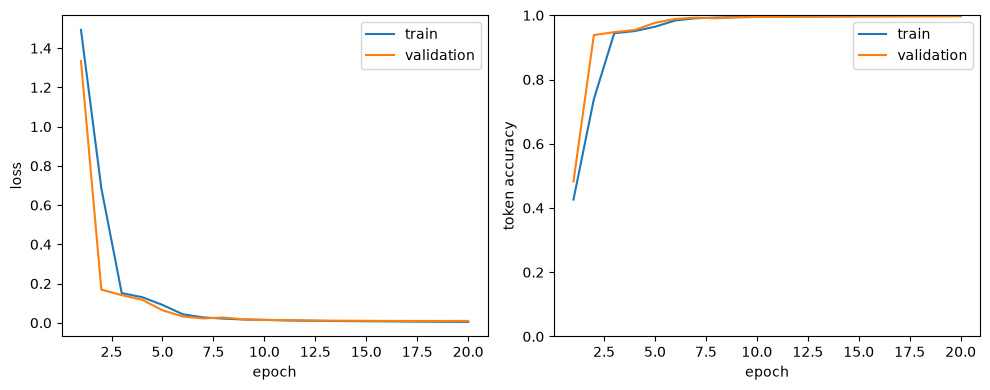

In [8]:
epochs = range(1, len(history.train) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [metrics.loss for metrics in history.train], label="train")
plt.plot(epochs, [metrics.loss for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [metrics.accuracy for metrics in history.train], label="train")
plt.plot(epochs, [metrics.accuracy for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("token accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

In [9]:
print("After training:")
show_generations(model, tokenizer, custom_examples)

final_train = history.train[-1]
final_validation = history.validation[-1]
print(
    f"final train loss={final_train.loss:.4f}, "
    f"train acc={final_train.accuracy:.3f}, "
    f"val loss={final_validation.loss:.4f}, "
    f"val acc={final_validation.accuracy:.3f}"
)

After training:
    0+0= -> 0+0=11
    5+7= -> 5+7=77
    9+1= -> 9+1=43
   10+5= -> 10+5=01
  45+54= -> 45+54=77
   99+1= -> 99+1=27
123+456= -> 123+456=579
  999+1= -> 999+1=188
 745+84= -> 745+84=880
 12+385= -> 12+385=397
 1000+0= -> 1000+0=1000
1005+2000= -> 1005+2000=3005
1234+1111= -> 1234+1111=2345
4096+2048= -> 4096+2048=6144
 9999+1= -> 9999+1=9111
9999+9999= -> 9999+9999=19998
final train loss=0.0047, train acc=0.998, val loss=0.0097, val acc=0.997


In [10]:
latest_checkpoint = checkpoint_manager.latest_checkpoint()
print(f"latest checkpoint: {latest_checkpoint}\n")

inference_model = SimpleTransformerLM(model_config)
checkpoint_manager.load_checkpoint(
    latest_checkpoint,
    model=inference_model,
    map_location=device,
)
inference_model = inference_model.to(device)

show_generations(inference_model, tokenizer, custom_examples)

latest checkpoint: ../checkpoints/addition-20260619-193654/epoch-0020.pt

    0+0= -> 0+0=11
    5+7= -> 5+7=77
    9+1= -> 9+1=43
   10+5= -> 10+5=01
  45+54= -> 45+54=77
   99+1= -> 99+1=27
123+456= -> 123+456=579
  999+1= -> 999+1=188
 745+84= -> 745+84=880
 12+385= -> 12+385=397
 1000+0= -> 1000+0=1000
1005+2000= -> 1005+2000=3005
1234+1111= -> 1234+1111=2345
4096+2048= -> 4096+2048=6144
 9999+1= -> 9999+1=9111
9999+9999= -> 9999+9999=19998
